# Truncated-Wigner simulation analysis

This notebook analyses the trajectory ensembles generated for the single-pump and two-pump cavity-mediated pair-creation models.

The analysis proceeds in four stages:

1. verification of the simulation data and initial Wigner sampling,
2. pair populations and population imbalance,
3. relative-number squeezing, metrological gain, and Cauchy--Schwarz correlations,
4. pair coherence and its sensitivity to shot-to-shot pump-phase fluctuations.

The phase-noise analysis compares simulations with mean relative pump phases

\begin{equation*}
    \bar{\phi}=0, \qquad  \bar{\phi}=\frac{\pi}{2} \qquad \text{and} \qquad \bar{\phi}=\pi
\end{equation*}

for phase-noise standard deviations ranging from $\sigma_\phi=0$ to $\sigma_\phi=\pi$.

In [41]:
from __future__ import annotations

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

from twa.observables import (
    PAIR_CHANNELS,
    compute_observables,
    mode_population_samples,
)

In [42]:
# Plotting style
plt.style.use(["science", "notebook", "grid", "high-contrast"])

In [43]:
# Project paths
PROJECT_ROOT = Path.cwd()

DATA_DIRECTORY = PROJECT_ROOT / "data"
PHASE_NOISE_DIRECTORY = DATA_DIRECTORY / "phase_noise_sweep"
PLOT_DIRECTORY = PROJECT_ROOT / "figures"

PLOT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Project root:          {PROJECT_ROOT}")
print(f"Data directory:        {DATA_DIRECTORY}")
print(f"Phase-noise directory: {PHASE_NOISE_DIRECTORY}")
print(f"Plot directory:        {PLOT_DIRECTORY}")

Project root:          /Users/kemaloenen/Library/CloudStorage/OneDrive-Persönlich/Uni (2)/Master Physik/qo-assistantship/twa_project
Data directory:        /Users/kemaloenen/Library/CloudStorage/OneDrive-Persönlich/Uni (2)/Master Physik/qo-assistantship/twa_project/data
Phase-noise directory: /Users/kemaloenen/Library/CloudStorage/OneDrive-Persönlich/Uni (2)/Master Physik/qo-assistantship/twa_project/data/phase_noise_sweep
Plot directory:        /Users/kemaloenen/Library/CloudStorage/OneDrive-Persönlich/Uni (2)/Master Physik/qo-assistantship/twa_project/figures


In [44]:
# Mode conventions
MODE_LABELS = {
    0: r"$N_{0}$",
    1: r"$N_{+k,+1}$",
    2: r"$N_{-k,-1}$",
    3: r"$N_{+k,-1}$",
    4: r"$N_{-k,+1}$",
    5: r"$N_{\pm 2k,0}$",
}

PAIR_CHANNELS = {
    "plus": (1, 2),
    "minus": (3, 4),
}

In [45]:
# check files
single_pump_files = sorted(
    DATA_DIRECTORY.glob("single_pump_*.npz")
)

two_pump_files = sorted(
    DATA_DIRECTORY.glob("two_pump_*.npz")
)

phase_noise_files = sorted(
    PHASE_NOISE_DIRECTORY.glob("two_pump_*.npz")
)

print(f"Single-pump files: {len(single_pump_files)}")
print(f"Two-pump files:    {len(two_pump_files)}")
print(f"Phase-noise files: {len(phase_noise_files)}")

Single-pump files: 1
Two-pump files:    6
Phase-noise files: 30


## Basic diagnostics

In [46]:
# Load the single-pump and two-pump simulations

single_pump_file = single_pump_files[-1] # latest
two_pump_file = two_pump_files[-1] # latest

def load_simulation(file_path):
    with np.load(file_path, allow_pickle=False) as data:
        simulation = {
            key: np.array(data[key], copy=True)
            for key in data.files
            if key != "metadata_json"
        }

        simulation["metadata"] = json.loads(
            str(data["metadata_json"].item())
        )

    simulation["file_path"] = file_path

    return simulation

In [47]:
# Load both datasets

single_pump_data = load_simulation(single_pump_file)
two_pump_data = load_simulation(two_pump_file)

In [48]:
def diagnose_simulation(simulation, label):
    time_ms = simulation["time_ms"]
    trajectories = simulation["trajectories"]
    mode_names = simulation["mode_names"]
    sampled_atom_numbers = simulation["sampled_atom_numbers"]
    metadata = simulation["metadata"]

    # Structural checks
    checks = {
        "3D trajectory array": trajectories.ndim == 3,
        "Six modes": trajectories.shape[1] == 6,
        "Time dimension matches": trajectories.shape[2] == len(time_ms),
        "Complex trajectory data": np.iscomplexobj(trajectories),
        "Finite trajectory data": np.all(np.isfinite(trajectories)),
        "Finite time array": np.all(np.isfinite(time_ms)),
        "Increasing time array": np.all(np.diff(time_ms) > 0),
        "No empty dimensions": all(size > 0 for size in trajectories.shape),
    }

    if not all(checks.values()):
        failed_checks = [
            name for name, passed in checks.items()
            if not passed
        ]
        raise ValueError(
            f"{label} failed the following checks: {failed_checks}"
        )

    # Concise dataset information
    summary = {
        "dataset": label,
        "file": simulation["file_path"].name,
        "model": metadata.get("model", "not available"),
        "trajectories": trajectories.shape[0],
        "modes": trajectories.shape[1],
        "time points": trajectories.shape[2],
        "time range [ms]":
            f"{time_ms[0]:.3f}–{time_ms[-1]:.3f}",
        "mean sampled atom number":
            sampled_atom_numbers.mean(),
        "trajectory dtype": trajectories.dtype,
    }

    simulation_parameters = metadata.get(
        "simulation_parameters", {}
    )

    summary["random seed"] = simulation_parameters.get(
        "random_seed", "not available"
    )

    # Phase information only exists for the two-pump run
    if "sampled_relative_phases_rad" in simulation:
        sampled_phases = simulation[
            "sampled_relative_phases_rad"
        ]

        summary["mean sampled phase [rad]"] = (
            sampled_phases.mean()
        )
        summary["sampled phase std [rad]"] = (
            sampled_phases.std(ddof=1)
        )

    # Initial Wigner populations
    initial_wigner_population = (
        np.abs(trajectories[:, :, 0]) ** 2
    )

    initial_corrected_population = (
        initial_wigner_population - 0.5
    )

    initial_population_table = pd.DataFrame({
        "dataset": label,
        "mode": np.arange(trajectories.shape[1]),
        "mode name": mode_names,
        "mean |α|²":
            initial_wigner_population.mean(axis=0),
        "mean corrected population":
            initial_corrected_population.mean(axis=0),
        "standard error":
            initial_corrected_population.std(
                axis=0, ddof=1
            ) / np.sqrt(trajectories.shape[0]),
    })

    return summary, initial_population_table

In [49]:
single_summary, single_initial = diagnose_simulation(
    single_pump_data,
    "Single pump",
)

two_summary, two_initial = diagnose_simulation(
    two_pump_data,
    "Two pump",
)


# Display dataset summaries
diagnostic_summary = pd.DataFrame([
    single_summary,
    two_summary,
]).set_index("dataset")

display(diagnostic_summary.T)


# Display initial Wigner sampling for both runs
initial_population_summary = pd.concat(
    [single_initial, two_initial],
    ignore_index=True,
)

display(
    initial_population_summary.style.format({
        "mean |α|²": "{:.4f}",
        "mean corrected population": "{:.4f}",
        "standard error": "{:.4f}",
    })
)

print("All structural checks passed for both datasets.")

dataset,Single pump,Two pump
file,single_pump_20260730_191317.npz,two_pump_phi_0p000_sigma_0p000_20260731_034516...
model,single_pump,two_pump
trajectories,1000,1000
modes,6,6
time points,2000,2000
time range [ms],0.000–0.200,0.000–0.200
mean sampled atom number,49955.797677,49955.797677
trajectory dtype,complex128,complex128
random seed,12345,12345
mean sampled phase [rad],NaN,0.0


,dataset,mode,mode name,mean |α|²,mean corrected population,standard error
0,Single pump,0,"(0,0)",49967.1064,49966.6064,78.5802
1,Single pump,1,"(+k,+1)",0.5298,0.0298,0.0169
2,Single pump,2,"(-k,-1)",0.4896,-0.0104,0.0157
3,Single pump,3,"(+k,-1)",0.4871,-0.0129,0.0155
4,Single pump,4,"(-k,+1)",0.5027,0.0027,0.0157
5,Single pump,5,"(+-2kx,0)",0.5054,0.0054,0.0162
6,Two pump,0,"(0,F=1,mF=0)",49967.1064,49966.6064,78.5802
7,Two pump,1,"(+k,F=2,mF=+1)",0.5298,0.0298,0.0169
8,Two pump,2,"(-k,F=2,mF=-1)",0.4896,-0.0104,0.0157
9,Two pump,3,"(+k,F=2,mF=-1)",0.4871,-0.0129,0.0155


All structural checks passed for both datasets.


## Population dynamics

In [50]:
# Compute observables for both simulations

single_pump_observables = compute_observables(
    single_pump_data["trajectories"]
)

two_pump_observables = compute_observables(
    two_pump_data["trajectories"]
)

single_time_us = single_pump_data["time_ms"] * 1000.0
two_time_us = two_pump_data["time_ms"] * 1000.0

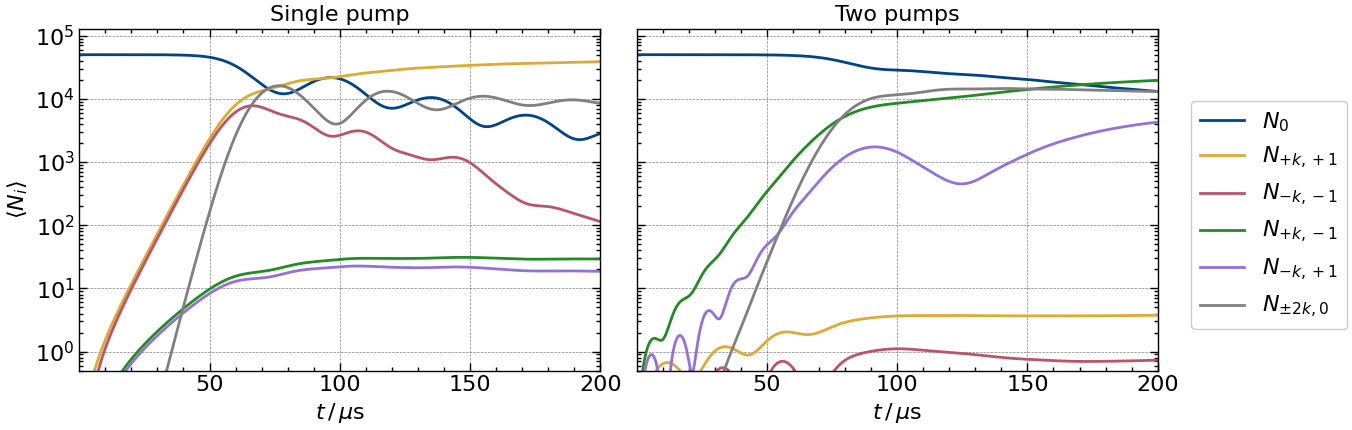

In [51]:
# Weyl-corrected mode populations

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.5),
    sharey=True,
)

datasets = [
    (
        axes[0],
        single_time_us,
        single_pump_observables,
        "Single pump",
    ),
    (
        axes[1],
        two_time_us,
        two_pump_observables,
        "Two pumps",
    ),
]

mode_colours = {
    3: "forestgreen",
    4: "mediumpurple",
    5: "grey",
}

for axis, time_us, observables, title in datasets:

    for mode_index in range(6):
        population = observables.mode_populations.mean[
            mode_index
        ]

        valid = population > 0.0

        plot_kwargs = {}

        if mode_index in mode_colours:
            plot_kwargs["color"] = mode_colours[mode_index]

        axis.plot(
            time_us[valid],
            population[valid],
            label=MODE_LABELS[mode_index],
            **plot_kwargs,
        )

    axis.set_yscale("log")
    axis.set_xlim(0.1, 200)
    axis.set_ylim(0.5, None)

    axis.set_xlabel(r"$t\,/\,\mu\mathrm{s}$")
    axis.set_title(title)

axes[0].set_ylabel(r"$\langle N_i\rangle$")

# Use the labels from the first panel for one common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.85, 0.5),
    ncol=1,
    frameon=True,
)

# Leave space on the right for the common legend
fig.tight_layout(rect=(0, 0, 0.86, 1))
plt.savefig("plots/populations_full_comparison.pdf", dpi=400)
plt.show()

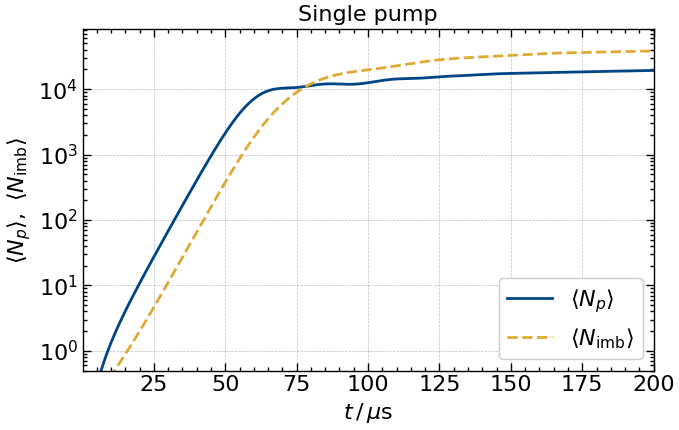

In [52]:
# Single-pump pair number and population imbalance

single_channel = single_pump_observables.pair_channels["plus"]

pair_number = single_channel.pair_number.mean
imbalance = np.abs(single_channel.population_difference.mean)

valid_pair = pair_number > 0.0
valid_imbalance = imbalance > 0.0

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    single_time_us[valid_pair],
    pair_number[valid_pair],
    linewidth=2.0,
    label=r"$\langle N_p\rangle$",
)

ax.plot(
    single_time_us[valid_imbalance],
    imbalance[valid_imbalance],
    linestyle="--",
    linewidth=2.0,
    label=r"$\langle N_{\mathrm{imb}}\rangle$",
)

ax.set_yscale("log")
ax.set_xlim(0.1, 200)
ax.set_ylim(0.5, None)

ax.set_xlabel(r"$t\,/\,\mu\mathrm{s}$")
ax.set_ylabel(
    r"$\langle N_p\rangle,\ \langle N_{\mathrm{imb}}\rangle$"
)
ax.set_title("Single pump")

ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()
plt.savefig("plots/population_imbalance_sp.pdf", dpi=400)
plt.show()

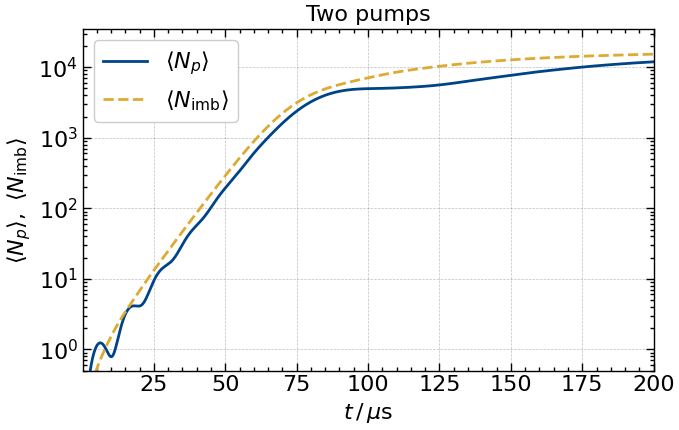

In [53]:
# Two-pump pair number and population imbalance

two_channel = two_pump_observables.pair_channels["minus"] # dominant channel here

pair_number = two_channel.pair_number.mean
imbalance = np.abs(two_channel.population_difference.mean)

valid_pair = pair_number > 0.0
valid_imbalance = imbalance > 0.0

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    two_time_us[valid_pair],
    pair_number[valid_pair],
    linewidth=2.0,
    label=r"$\langle N_p\rangle$",
)

ax.plot(
    two_time_us[valid_imbalance],
    imbalance[valid_imbalance],
    linestyle="--",
    linewidth=2.0,
    label=r"$\langle N_{\mathrm{imb}}\rangle$",
)

ax.set_yscale("log")
ax.set_xlim(0.1, 200)
ax.set_ylim(0.5, None)

ax.set_xlabel(r"$t\,/\,\mu\mathrm{s}$")
ax.set_ylabel(
    r"$\langle N_p\rangle,\ \langle N_{\mathrm{imb}}\rangle$"
)
ax.set_title("Two pumps")

ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()
plt.savefig("plots/population_imbalance_tp.pdf", dpi=400)
plt.show()

## Relative-number squeezing, gain and Cauchy-Schwarz ratio

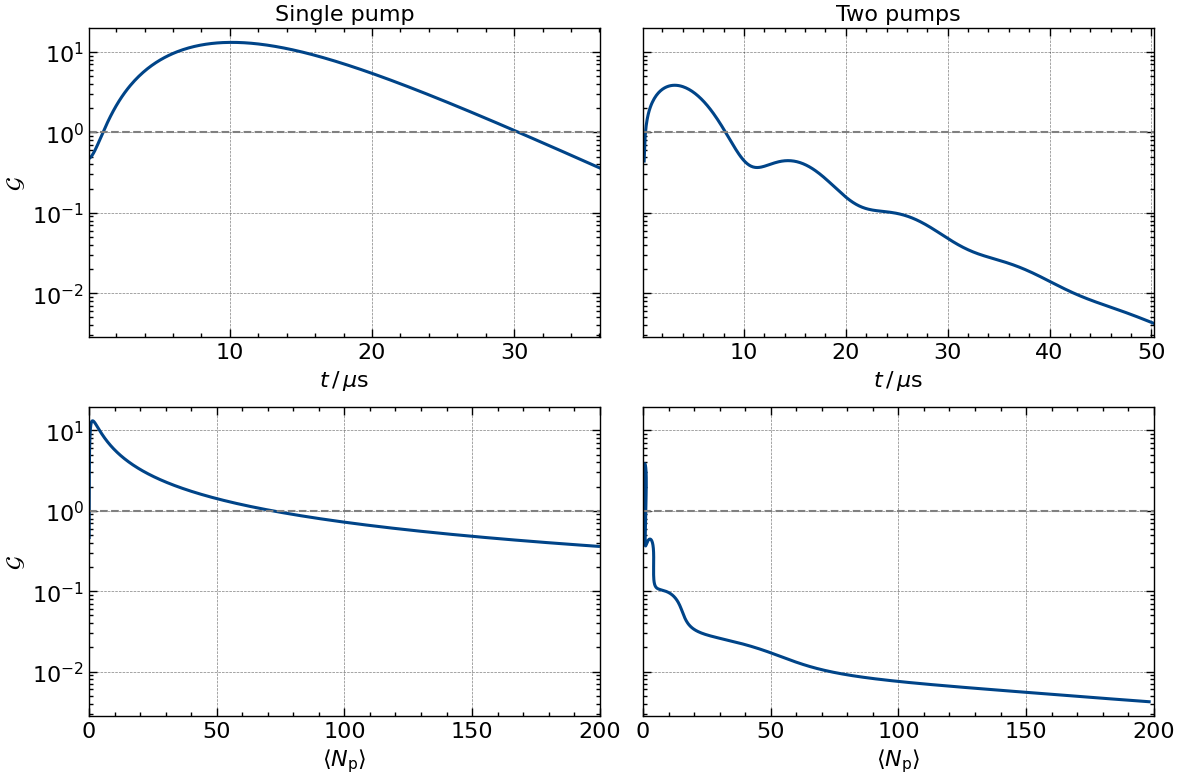

In [54]:
# Metrological gain in the early pair-production regime
# top row    -> versus simulation time
# bottom row -> versus mean pair number

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharey=True,
)

datasets = [
    (
        single_time_us,
        single_pump_observables.pair_channels["plus"],
        "Single pump",
    ),
    (
        two_time_us,
        two_pump_observables.pair_channels["minus"],
        "Two pumps",
    ),
]

threshold_colour = "grey"
pair_number_max = 200.0

for column, (time_us, channel, title) in enumerate(datasets):

    gain = np.asarray(
        channel.metrological_gain,
        dtype=float,
    )

    pair_number = np.asarray(
        channel.pair_number.mean,
        dtype=float,
    )

    time_us = np.asarray(
        time_us,
        dtype=float,
    )

    # Restrict both plots to the regime Np <= 300
    valid = (
        np.isfinite(time_us)
        & np.isfinite(pair_number)
        & np.isfinite(gain)
        & (pair_number > 0.0)
        & (pair_number <= pair_number_max)
        & (gain > 0.0)
    )

    time_restricted = time_us[valid]
    pair_number_restricted = pair_number[valid]
    gain_restricted = gain[valid]

    # Top row: gain versus simulation time
    axes[0, column].plot(
        time_restricted,
        gain_restricted,
        linewidth=2.2,
    )

    axes[0, column].axhline(
        1.0,
        color=threshold_colour,
        linestyle="--",
        linewidth=1.5,
    )

    axes[0, column].set_yscale("log")

    if time_restricted.size > 0:
        axes[0, column].set_xlim(
            0.1,
            time_restricted.max(),
        )

    axes[0, column].set_xlabel(
        r"$t\,/\,\mu\mathrm{s}$"
    )
    axes[0, column].set_title(title)

    # Bottom row: gain versus mean pair number
    axes[1, column].plot(
        pair_number_restricted,
        gain_restricted,
        linewidth=2.2,
    )

    axes[1, column].axhline(
        1.0,
        color=threshold_colour,
        linestyle="--",
        linewidth=1.5,
    )

    axes[1, column].set_yscale("log")
    axes[1, column].set_xlim(0.0, pair_number_max)

    axes[1, column].set_xlabel(
        r"$\langle N_{\mathrm{p}}\rangle$"
    )

axes[0, 0].set_ylabel(
    r"$\mathcal{G}$"
)

axes[1, 0].set_ylabel(
    r"$\mathcal{G}$"
)

fig.tight_layout()
plt.savefig("plots/gain_both.pdf", dpi=500)
plt.show()

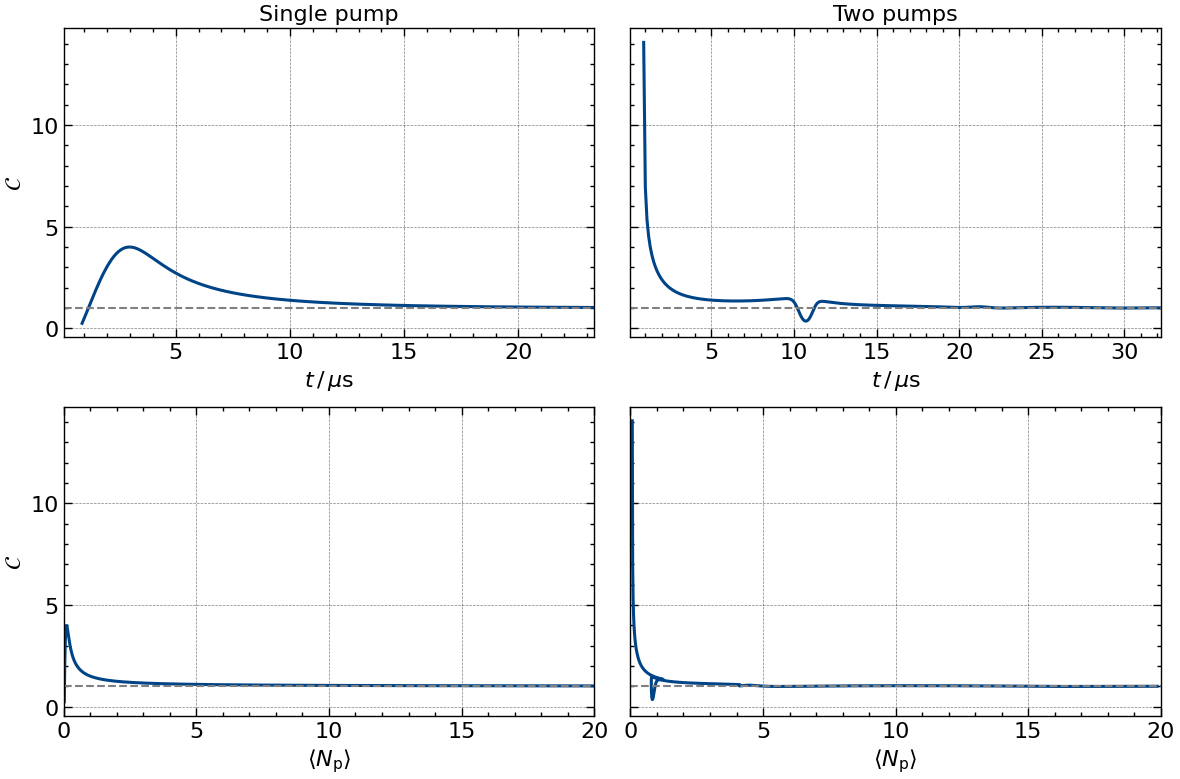

In [55]:
# Cauchy-Schwarz ratio in the early pair-production regime
# top row    -> versus simulation time
# bottom row -> versus mean pair number

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharey=True,
)

datasets = [
    (
        single_time_us,
        single_pump_observables.pair_channels["plus"],
        "Single pump",
    ),
    (
        two_time_us,
        two_pump_observables.pair_channels["minus"],
        "Two pumps",
    ),
]

pair_number_max = 20.0
threshold_colour = "grey"

for column, (time_us, channel, title) in enumerate(datasets):

    cs_ratio = np.asarray(
        channel.cauchy_schwarz_ratio,
        dtype=float,
    )

    pair_number = np.asarray(
        channel.pair_number.mean,
        dtype=float,
    )

    time_us = np.asarray(
        time_us,
        dtype=float,
    )

    valid = (
        np.isfinite(time_us)
        & np.isfinite(pair_number)
        & np.isfinite(cs_ratio)
        & (pair_number > 0.0)
        & (pair_number <= pair_number_max)
        & (cs_ratio > 0.0)
    )

    time_restricted = time_us[valid]
    pair_number_restricted = pair_number[valid]
    cs_restricted = cs_ratio[valid]

    # Top row: CS ratio versus simulation time
    axes[0, column].plot(
        time_restricted,
        cs_restricted,
        linewidth=2.2,
    )

    axes[0, column].axhline(
        1.0,
        color=threshold_colour,
        linestyle="--",
        linewidth=1.5,
    )

    if time_restricted.size > 0:
        axes[0, column].set_xlim(
            0.1,
            time_restricted.max(),
        )

    axes[0, column].set_xlabel(
        r"$t\,/\,\mu\mathrm{s}$"
    )
    axes[0, column].set_title(title)

    # Bottom row: CS ratio versus mean pair number
    axes[1, column].plot(
        pair_number_restricted,
        cs_restricted,
        linewidth=2.2,
    )

    axes[1, column].axhline(
        1.0,
        color=threshold_colour,
        linestyle="--",
        linewidth=1.5,
    )

    axes[1, column].set_xlim(0.0, pair_number_max)

    axes[1, column].set_xlabel(
        r"$\langle N_{\mathrm{p}}\rangle$"
    )

axes[0, 0].set_ylabel(
    r"$\mathcal{C}$"
)

axes[1, 0].set_ylabel(
    r"$\mathcal{C}$"
)

fig.tight_layout()
plt.savefig("plots/cs_both.pdf", dpi=500)
plt.show()

## Pair coherence

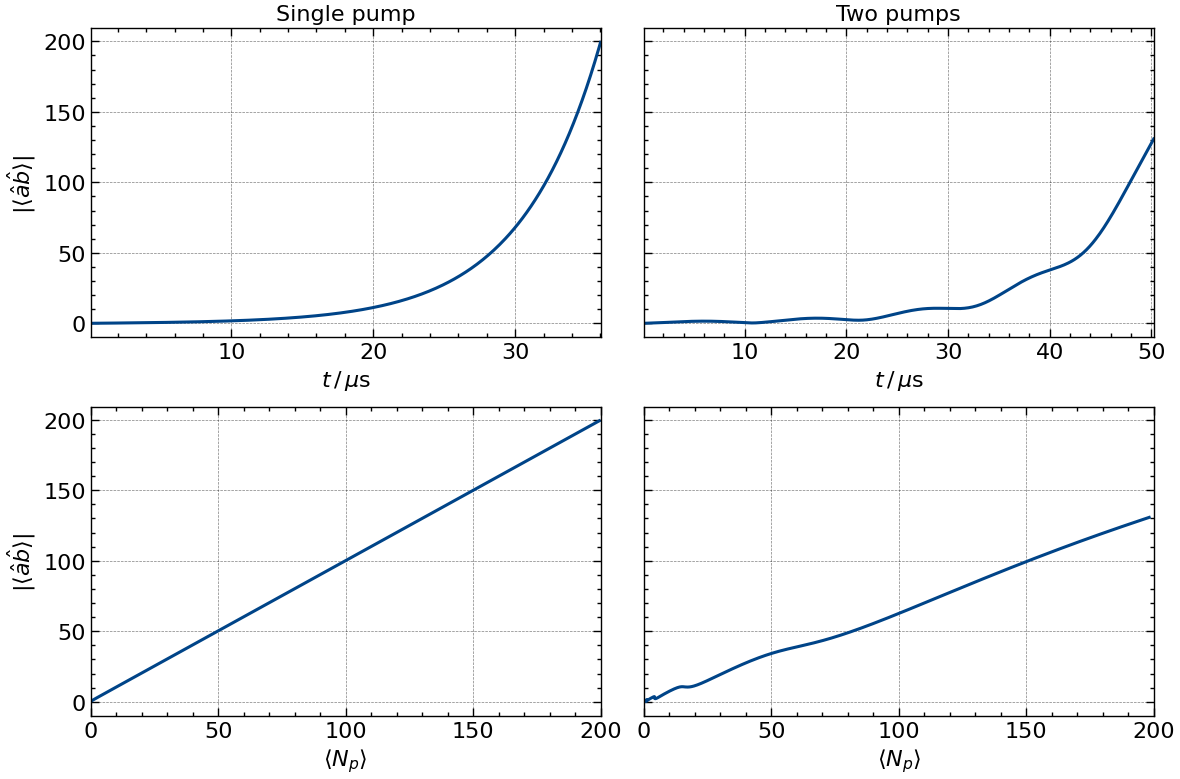

In [56]:
# Magnitude of the pair coherence

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharey=True,
)

datasets = [
    (
        single_time_us,
        single_pump_observables.pair_channels["plus"],
        "Single pump",
    ),
    (
        two_time_us,
        two_pump_observables.pair_channels["minus"],
        "Two pumps",
    ),
]

pair_number_max = 200.0

for column, (time_us, channel, title) in enumerate(datasets):

    coherence = np.asarray(
        channel.pair_coherence.mean,
        dtype=complex,
    )

    magnitude = np.abs(coherence)

    pair_number = np.asarray(
        channel.pair_number.mean,
        dtype=float,
    )

    time_us = np.asarray(
        time_us,
        dtype=float,
    )

    valid = (
        np.isfinite(time_us)
        & np.isfinite(pair_number)
        & np.isfinite(magnitude)
        & (pair_number > 0.0)
        & (pair_number <= pair_number_max)
    )

    time_plot = time_us[valid]
    pair_plot = pair_number[valid]
    magnitude_plot = magnitude[valid]

    # Magnitude versus time
    axes[0, column].plot(
        time_plot,
        magnitude_plot,
        linewidth=2.2,
    )

    if time_plot.size > 0:
        axes[0, column].set_xlim(
            0.1,
            time_plot.max(),
        )

    axes[0, column].set_xlabel(
        r"$t\,/\,\mu\mathrm{s}$"
    )
    axes[0, column].set_title(title)

    # Magnitude versus pair number
    axes[1, column].plot(
        pair_plot,
        magnitude_plot,
        linewidth=2.2,
    )

    axes[1, column].set_xlim(
        0.0,
        pair_number_max,
    )

    axes[1, column].set_xlabel(
        r"$\langle N_p\rangle$"
    )

axes[0, 0].set_ylabel(
    r"$|\langle \hat{a}\hat{b}\rangle|$"
)

axes[1, 0].set_ylabel(
    r"$|\langle \hat{a}\hat{b}\rangle|$"
)

fig.tight_layout()
plt.savefig("plots/pair_coherence_magnitude.pdf", dpi=400)
plt.show()

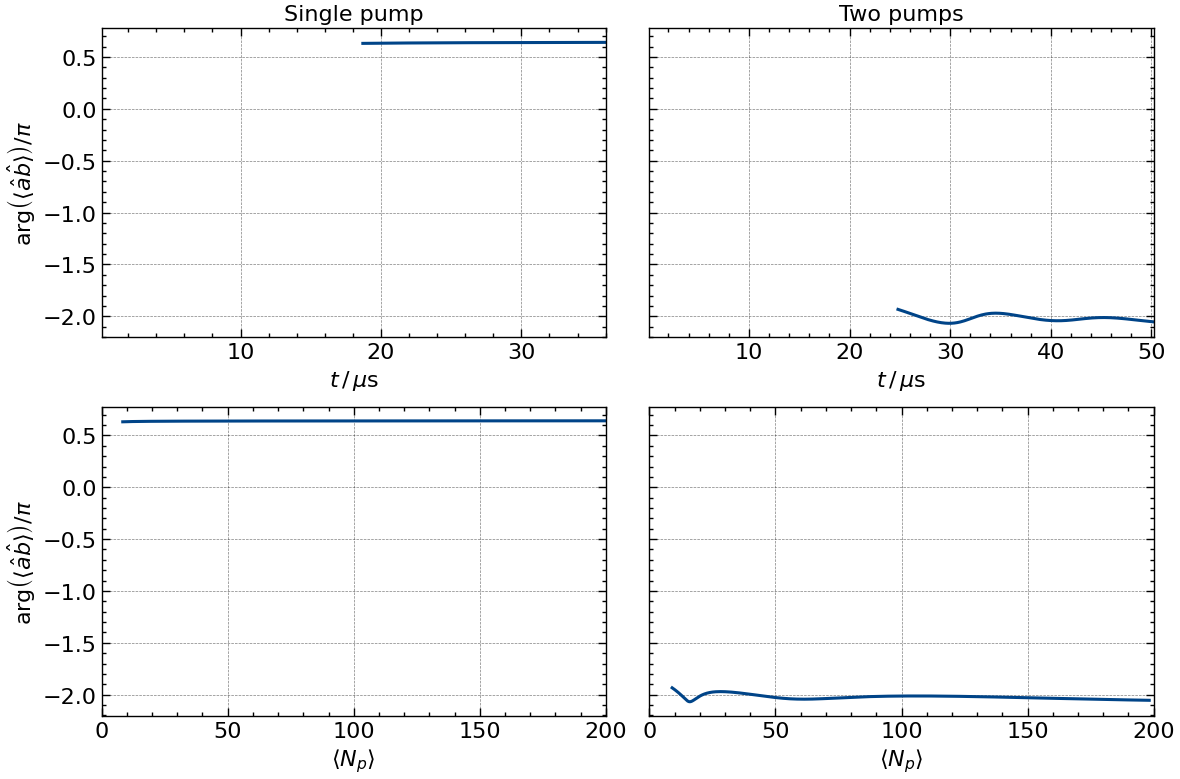

In [57]:
# Phase of the pair coherence
# top row    -> versus simulation time
# bottom row -> versus mean pair number
#
# Phase is shown in units of pi.

from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
    sharey=True,
)

datasets = [
    (
        single_time_us,
        single_pump_observables.pair_channels["plus"],
        "Single pump",
    ),
    (
        two_time_us,
        two_pump_observables.pair_channels["minus"],
        "Two pumps",
    ),
]

pair_number_max = 200.0
relative_cutoff = 1e-3

for column, (time_us, channel, title) in enumerate(datasets):

    coherence = np.asarray(
        channel.pair_coherence.mean,
        dtype=complex,
    )

    coherence_magnitude = np.abs(coherence)

    coherence_phase = (
        np.unwrap(np.angle(coherence))
        / np.pi
    )

    pair_number = np.asarray(
        channel.pair_number.mean,
        dtype=float,
    )

    time_us = np.asarray(
        time_us,
        dtype=float,
    )

    finite_magnitude = coherence_magnitude[
        np.isfinite(coherence_magnitude)
    ]

    if finite_magnitude.size > 0:
        magnitude_cutoff = (
            relative_cutoff
            * finite_magnitude.max()
        )
    else:
        magnitude_cutoff = 0.0

    valid = (
        np.isfinite(time_us)
        & np.isfinite(pair_number)
        & np.isfinite(coherence_magnitude)
        & np.isfinite(coherence_phase)
        & (pair_number > 0.0)
        & (pair_number <= pair_number_max)
        & (coherence_magnitude > magnitude_cutoff)
    )

    time_plot = time_us[valid]
    pair_number_plot = pair_number[valid]
    phase_plot = coherence_phase[valid]

    # Phase versus time
    axes[0, column].plot(
        time_plot,
        phase_plot,
        linewidth=2.2,
    )

    axes[0, column].set_title(title)

    axes[0, column].set_xlabel(
        r"$t\,/\,\mu\mathrm{s}$"
    )

    if time_plot.size > 0:
        axes[0, column].set_xlim(
            0.1,
            time_plot.max(),
        )

    # Phase versus pair number
    axes[1, column].plot(
        pair_number_plot,
        phase_plot,
        linewidth=2.2,
    )

    axes[1, column].set_xlim(
        0.0,
        pair_number_max,
    )

    axes[1, column].set_xlabel(
        r"$\langle N_p\rangle$"
    )

    axes[0, column].yaxis.set_major_locator(
        MultipleLocator(0.5)
    )

    axes[1, column].yaxis.set_major_locator(
        MultipleLocator(0.5)
    )

axes[0, 0].set_ylabel(
    r"$\arg\!\left(\langle \hat{a}\hat{b}\rangle\right)/\pi$"
)

axes[1, 0].set_ylabel(
    r"$\arg\!\left(\langle \hat{a}\hat{b}\rangle\right)/\pi$"
)

fig.tight_layout()
plt.savefig("plots/pair_coherence_phase.pdf", dpi=400)
plt.show()

## Phase-noise sweep

In [58]:
phase_sweep_directory = PHASE_NOISE_DIRECTORY

print(
    "Reading files from:",
    phase_sweep_directory.resolve(),
)


filename_pattern = re.compile(
    r"two_pump_phi_"
    r"(?P<phi>\d+p\d+)_"
    r"sigma_"
    r"(?P<sigma>\d+p\d+)_"
    r"(?P<timestamp>\d+_\d+)"
    r"\.npz$"
)


def decode_filename_value(value):
    """
    Convert filename notation such as 1p571 into 1.571.
    """
    return float(
        value.replace("p", ".")
    )


def nearest_grid_index(
    value,
    grid_values,
):
    """
    Return the index of the nearest exact sweep value.
    """
    return int(
        np.argmin(
            np.abs(
                grid_values - value
            )
        )
    )


# Exact physical sweep values
delta_phi_values = np.array([
    0.0,
    np.pi / 2.0,
    np.pi,
])

sigma_values = np.linspace(
    0.0,
    np.pi,
    10,
)


phase_noise_files = sorted(
    phase_sweep_directory.glob(
        "two_pump_phi_*.npz"
    )
)

print(
    f"Found {len(phase_noise_files)} files."
)


phase_sweep_data = {}


for file_path in phase_noise_files:

    match = filename_pattern.fullmatch(
        file_path.name
    )

    if match is None:
        print(
            "Skipped unrecognized file:",
            file_path.name,
        )
        continue

    phi_from_filename = decode_filename_value(
        match.group("phi")
    )

    sigma_from_filename = decode_filename_value(
        match.group("sigma")
    )

    phi_index = nearest_grid_index(
        phi_from_filename,
        delta_phi_values,
    )

    sigma_index = nearest_grid_index(
        sigma_from_filename,
        sigma_values,
    )

    simulation_data = load_simulation(
        file_path
    )

    simulation_observables = compute_observables(
        simulation_data["trajectories"]
    )

    phase_sweep_data[
        (phi_index, sigma_index)
    ] = {
        "delta_phi": delta_phi_values[
            phi_index
        ],
        "sigma": sigma_values[
            sigma_index
        ],
        "data": simulation_data,
        "observables": simulation_observables,
        "file_path": file_path,
    }


expected_number = (
    len(delta_phi_values)
    * len(sigma_values)
)

print(
    f"Loaded {len(phase_sweep_data)} "
    "phase-noise simulations."
)

print(
    f"Expected {expected_number} simulations."
)

Reading files from: /Users/kemaloenen/Library/CloudStorage/OneDrive-Persönlich/Uni (2)/Master Physik/qo-assistantship/twa_project/data/phase_noise_sweep
Found 30 files.
Loaded 30 phase-noise simulations.
Expected 30 simulations.


In [59]:
# Verify that the complete 3 x 10 sweep was loaded

for phi_index, delta_phi in enumerate(
    delta_phi_values
):

    missing_sigma_indices = []

    for sigma_index in range(
        len(sigma_values)
    ):

        if (
            phi_index,
            sigma_index,
        ) not in phase_sweep_data:

            missing_sigma_indices.append(
                sigma_index
            )

    if missing_sigma_indices:
        print(
            f"Missing for phi index "
            f"{phi_index}:",
            missing_sigma_indices,
        )
    else:
        print(
            f"Complete sweep for "
            f"delta phi = "
            f"{delta_phi / np.pi:.1f} pi"
        )

Complete sweep for delta phi = 0.0 pi
Complete sweep for delta phi = 0.5 pi
Complete sweep for delta phi = 1.0 pi


In [60]:
# Exact labels for the phase-noise widths

sigma_labels = [
    r"$0$",
    r"$\pi/9$",
    r"$2\pi/9$",
    r"$\pi/3$",
    r"$4\pi/9$",
    r"$5\pi/9$",
    r"$2\pi/3$",
    r"$7\pi/9$",
    r"$8\pi/9$",
    r"$\pi$",
]

delta_phi_labels = [
    r"$0$",
    r"$\pi/2$",
    r"$\pi$",
]

### Pair number and imbalance

In [61]:
# Pair number and population imbalance versus time

def plot_pair_number_imbalance_grid(
    phi_index,
):
    """
    Plot the mean pair number and absolute population imbalance
    versus time for all ten phase-noise widths at one fixed
    relative pump phase.
    """

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(16, 7),
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    for sigma_index, ax in enumerate(axes):

        result = phase_sweep_data[
            (phi_index, sigma_index)
        ]

        time_us = np.asarray(
            result["data"]["time_ms"],
            dtype=float,
        ) * 1000.0

        channel = (
            result["observables"]
            .pair_channels["minus"]
        )

        pair_number = np.asarray(
            channel.pair_number.mean,
            dtype=float,
        )

        imbalance = np.abs(
            np.asarray(
                channel.population_difference.mean,
                dtype=float,
            )
        )

        valid_pair = (
            np.isfinite(time_us)
            & np.isfinite(pair_number)
            & (pair_number > 0.0)
        )

        valid_imbalance = (
            np.isfinite(time_us)
            & np.isfinite(imbalance)
            & (imbalance > 0.0)
        )

        ax.plot(
            time_us[valid_pair],
            pair_number[valid_pair],
            linewidth=2.0,
            label=r"$\langle N_p\rangle$",
        )

        ax.plot(
            time_us[valid_imbalance],
            imbalance[valid_imbalance],
            linestyle="--",
            linewidth=2.0,
            label=r"$\langle N_{\mathrm{imb}}\rangle$",
        )

        ax.set_yscale("log")
        ax.set_xlim(0.1, 200)
        ax.set_ylim(0.5, None)

        ax.set_title(
            rf"$\sigma={sigma_labels[sigma_index][1:-1]}$"
        )

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(0.86, 0.5),
        frameon=True,
    )

    fig.supxlabel(
        r"$t\,/\,\mu\mathrm{s}$",
        fontsize=18,
    )

    fig.supylabel(
        r"$\langle N_p\rangle,\ "
        r"\langle N_{\mathrm{imb}}\rangle$",
        fontsize=18,
    )

    fig.suptitle(
        r"Relative pump phase "
        rf"$\Delta\phi="
        rf"{delta_phi_labels[phi_index][1:-1]}$",
        y=1.0,
        fontsize=20,
    )

    fig.tight_layout(
        rect=(0, 0, 0.86, 1)
    )

    return fig, axes

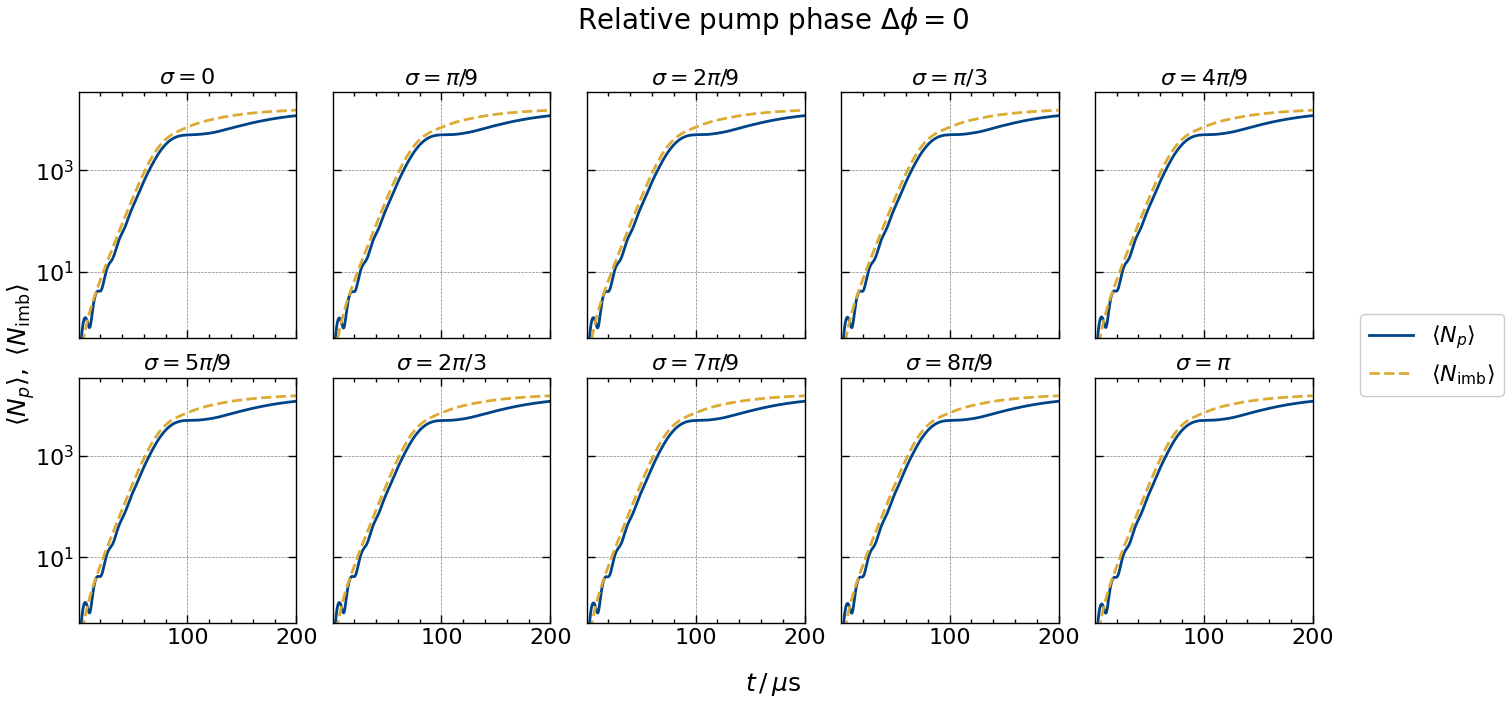

In [62]:
fig, axes = plot_pair_number_imbalance_grid(phi_index=0)
fig.savefig("plots/pair_number_imbalance_phi_0.pdf", dpi=400, bbox_inches="tight")
plt.show()

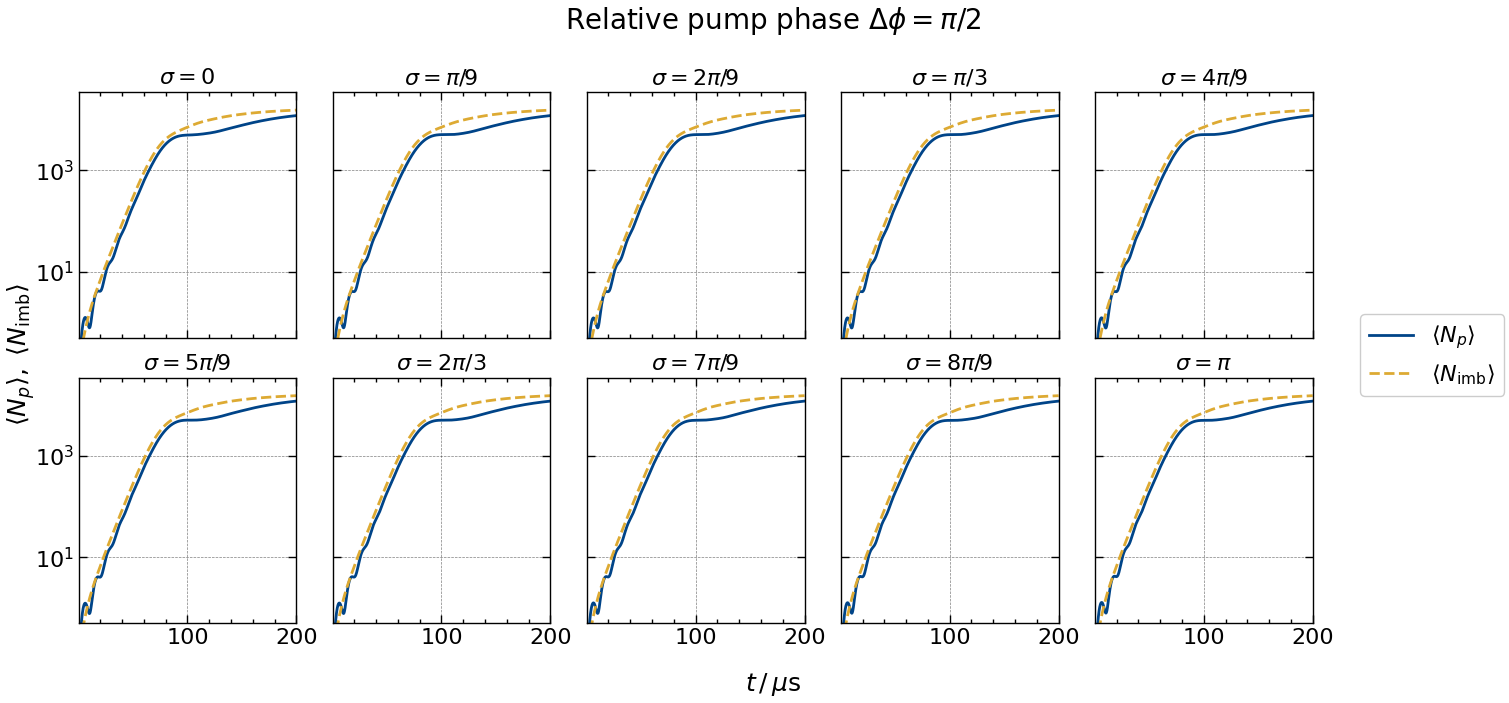

In [63]:
fig, axes = plot_pair_number_imbalance_grid(phi_index=1)
fig.savefig("plots/pair_number_imbalance_phi_pi_2.pdf", dpi=400, bbox_inches="tight")
plt.show()

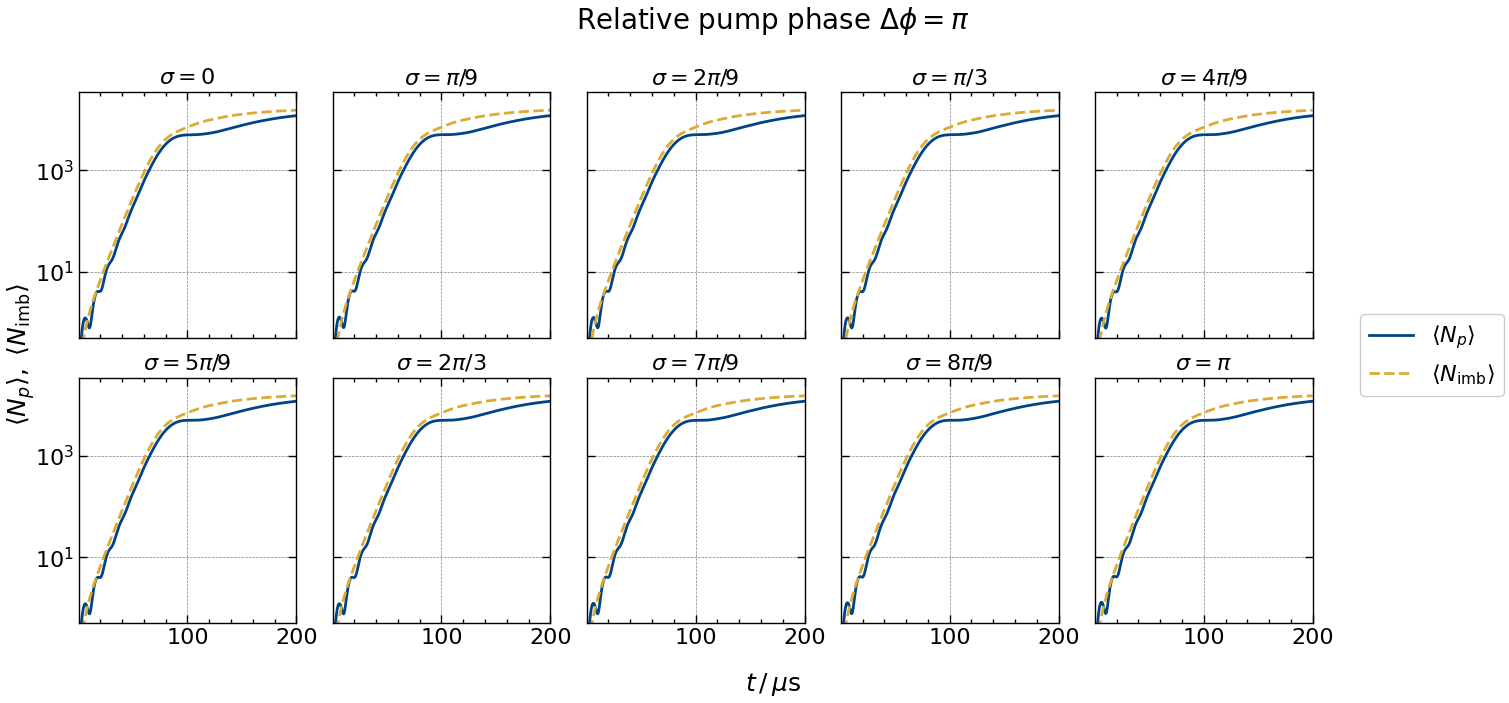

In [64]:
fig, axes = plot_pair_number_imbalance_grid(phi_index=2)
fig.savefig("plots/pair_number_imbalance_phi_pi.pdf", dpi=400, bbox_inches="tight")
plt.show()

### Metrological gain

In [65]:
def plot_gain_phase_noise_grid(
    phi_index,
    pair_number_max=10.0,
):
    """
    Plot metrological gain versus mean pair number
    for all ten phase-noise widths at one fixed
    relative pump phase.
    """

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(16, 7),
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    for sigma_index, ax in enumerate(
        axes
    ):

        result = phase_sweep_data[
            (phi_index, sigma_index)
        ]

        channel = (
            result["observables"]
            .pair_channels["minus"]
        )

        pair_number = np.asarray(
            channel.pair_number.mean,
            dtype=float,
        )

        gain = np.asarray(
            channel.metrological_gain,
            dtype=float,
        )

        valid = (
            np.isfinite(pair_number)
            & np.isfinite(gain)
            & (pair_number > 0.0)
            & (
                pair_number
                <= pair_number_max
            )
            & (gain > 0.0)
        )

        pair_number_plot = pair_number[
            valid
        ]

        gain_plot = gain[valid]

        ax.plot(
            pair_number_plot,
            gain_plot,
            linewidth=2.0,
        )

        ax.axhline(
            1.0,
            color="grey",
            linestyle="--",
            linewidth=1.3,
        )

        ax.set_yscale("log")

        ax.set_xlim(
            0.0,
            pair_number_max,
        )

        ax.set_title(
            rf"$\sigma={sigma_labels[sigma_index][1:-1]}$"
        )

    fig.supxlabel(
        r"$\langle N_p\rangle$",
        fontsize = 18,
    )

    fig.supylabel(
        r"$\mathcal{G}$",
        fontsize = 18,
    )

    fig.suptitle(
        r"Relative pump phase "
        rf"$\Delta\phi="
        rf"{delta_phi_labels[phi_index][1:-1]}$",
        y=1.0,
        fontsize = 20,
    )

    fig.tight_layout()

    return fig, axes

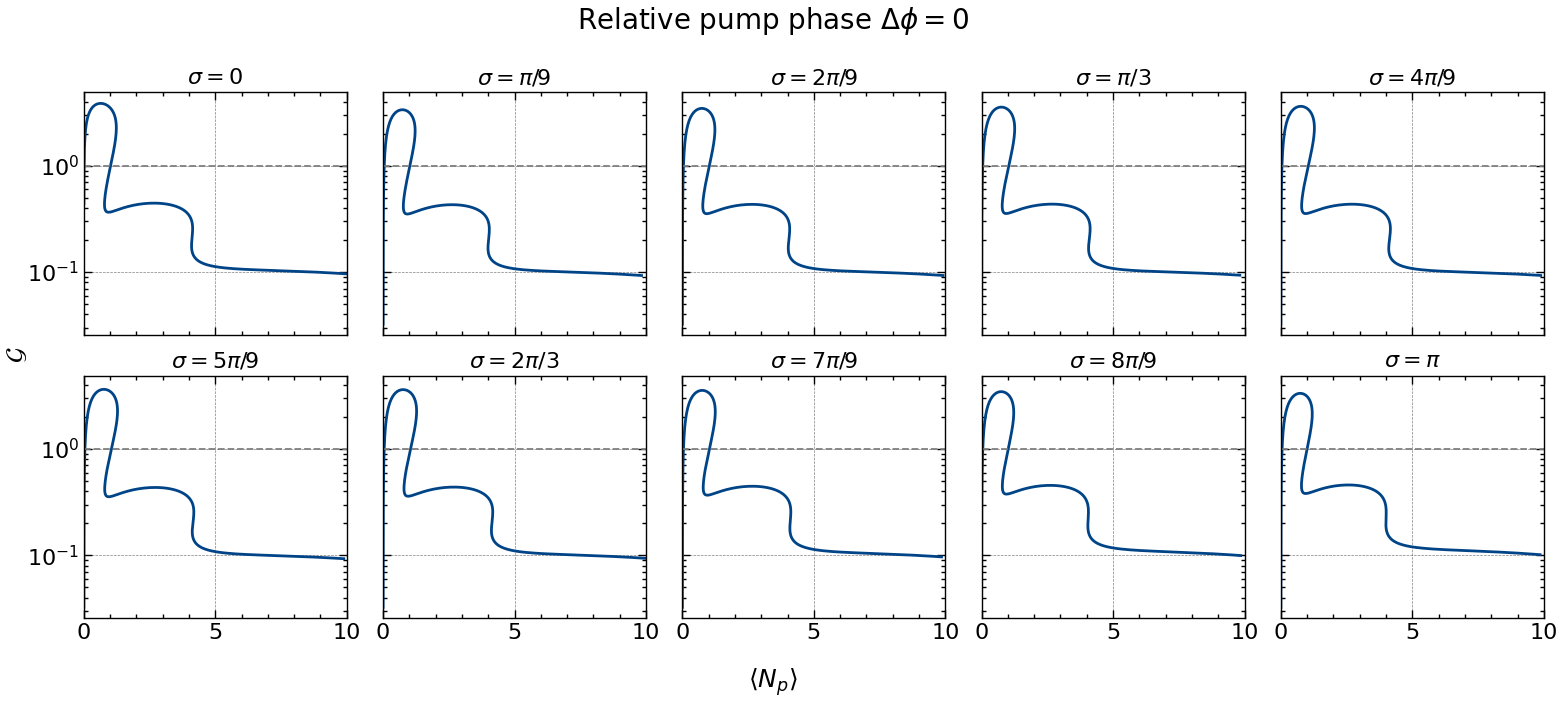

In [66]:
fig, axes = plot_gain_phase_noise_grid(
    phi_index=0,
)

plt.savefig("plots/gain_phase_noise_phi_0.pdf", dpi=500, bbox_inches="tight")
plt.show()

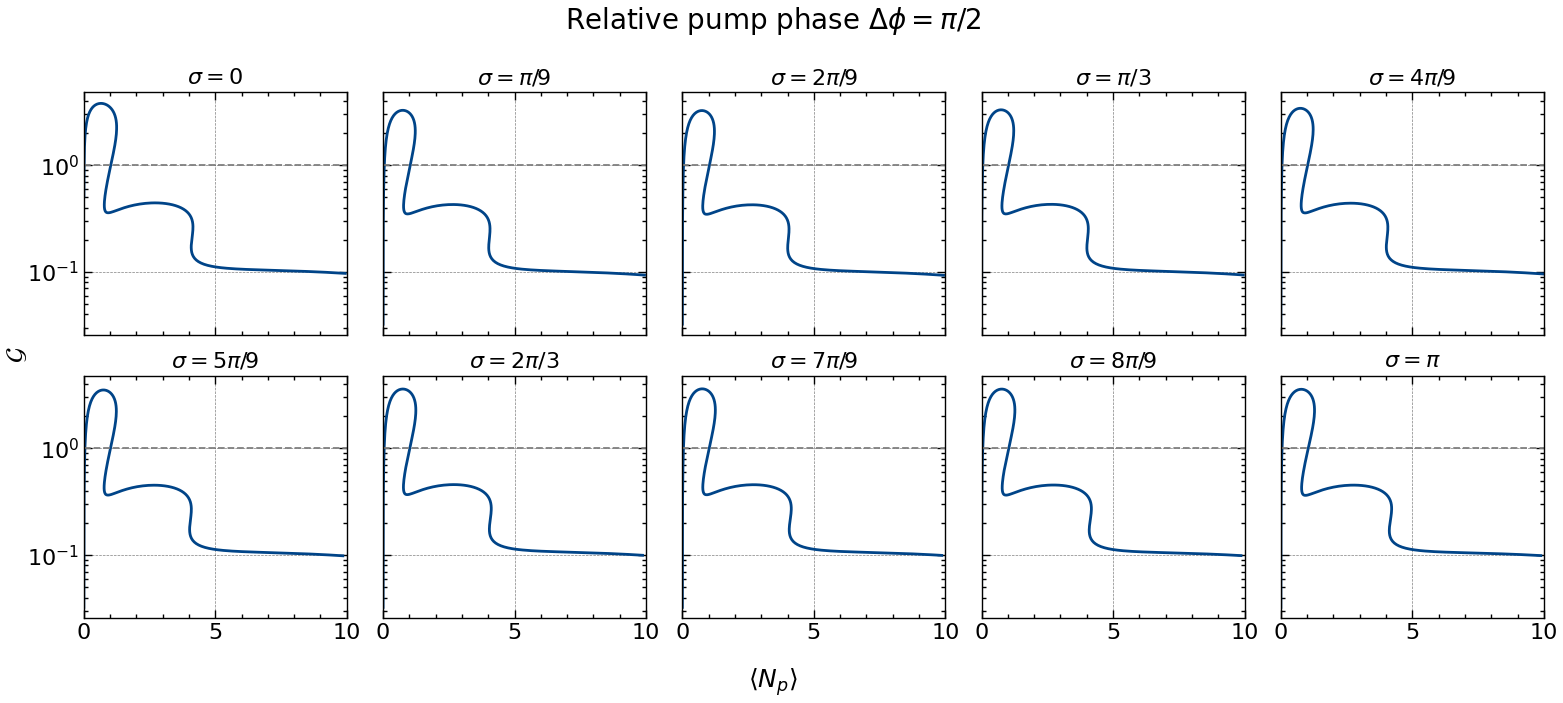

In [67]:
fig, axes = plot_gain_phase_noise_grid(
    phi_index=1,
)

plt.savefig("plots/gain_phase_noise_phi_pi_2.pdf", dpi=500, bbox_inches="tight")
plt.show()

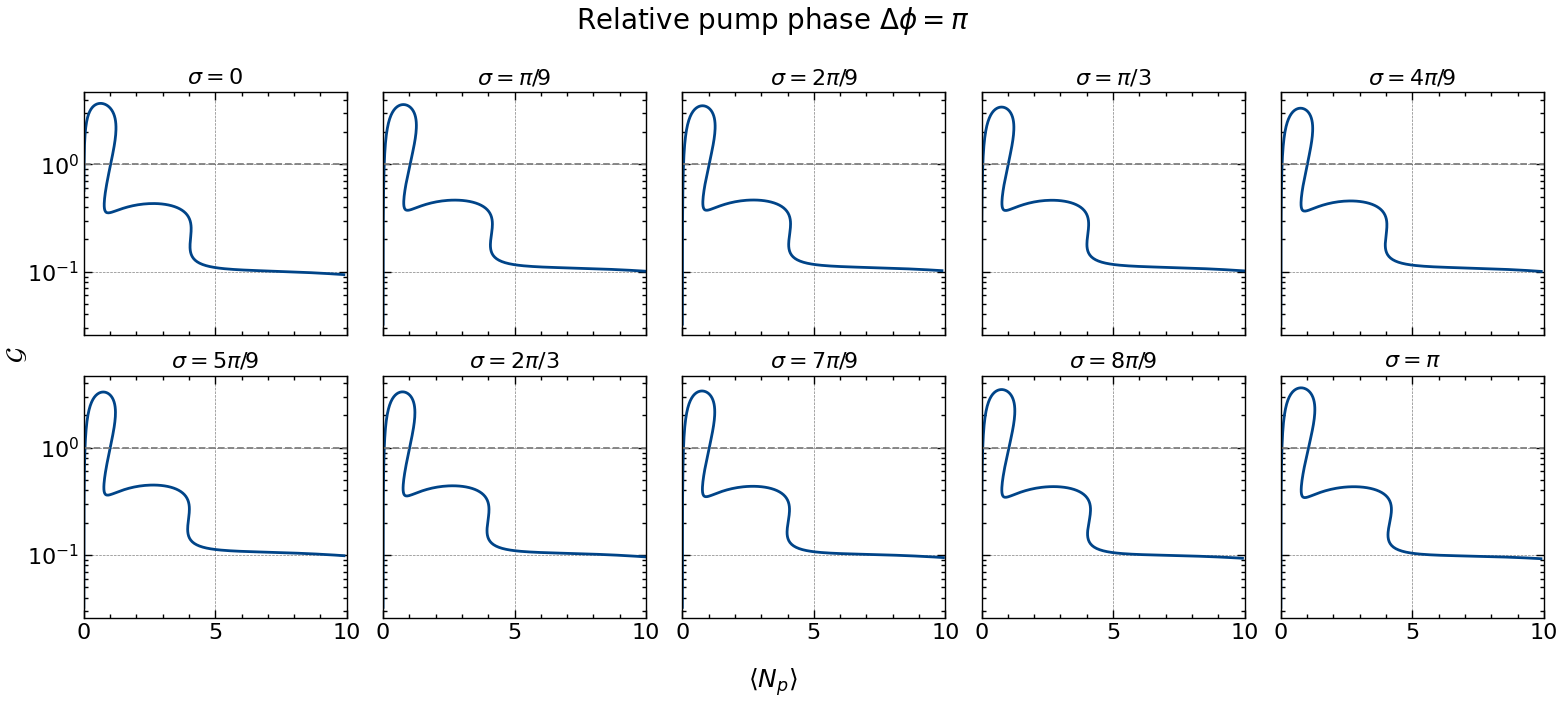

In [68]:
fig, axes = plot_gain_phase_noise_grid(
    phi_index=2,
)

plt.savefig("plots/gain_phase_noise_phi_pi.pdf", dpi=500, bbox_inches="tight")
plt.show()

### Pair coherence

In [69]:
# Pair-coherence magnitude versus mean pair number

def plot_pair_coherence_magnitude_grid(
    phi_index,
    pair_number_max=200.0,
):
    """
    Plot the pair-coherence magnitude versus mean pair number
    for all ten phase-noise widths at one fixed relative pump phase.
    """

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(16, 7),
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    for sigma_index, ax in enumerate(axes):

        result = phase_sweep_data[
            (phi_index, sigma_index)
        ]

        channel = (
            result["observables"]
            .pair_channels["minus"]
        )

        pair_number = np.asarray(
            channel.pair_number.mean,
            dtype=float,
        )

        pair_coherence = np.asarray(
            channel.pair_coherence.mean,
            dtype=complex,
        )

        coherence_magnitude = np.abs(
            pair_coherence
        )

        valid = (
            np.isfinite(pair_number)
            & np.isfinite(coherence_magnitude)
            & (pair_number > 0.0)
            & (pair_number <= pair_number_max)
        )

        pair_number_plot = pair_number[
            valid
        ]

        coherence_plot = coherence_magnitude[
            valid
        ]

        ax.plot(
            pair_number_plot,
            coherence_plot,
            linewidth=2.0,
        )

        ax.set_xlim(
            0.0,
            pair_number_max,
        )

        ax.set_title(
            rf"$\sigma={sigma_labels[sigma_index][1:-1]}$"
        )

    fig.supxlabel(
        r"$\langle N_p\rangle$",
        fontsize=18
    )

    fig.supylabel(
        r"$\left|\langle \hat{a}\hat{b}\rangle\right|$",
        fontsize=18
    )

    fig.suptitle(
        r"Relative pump phase "
        rf"$\Delta\phi="
        rf"{delta_phi_labels[phi_index][1:-1]}$",
        y=1.02,
        fontsize=20
    )

    fig.tight_layout()

    return fig, axes

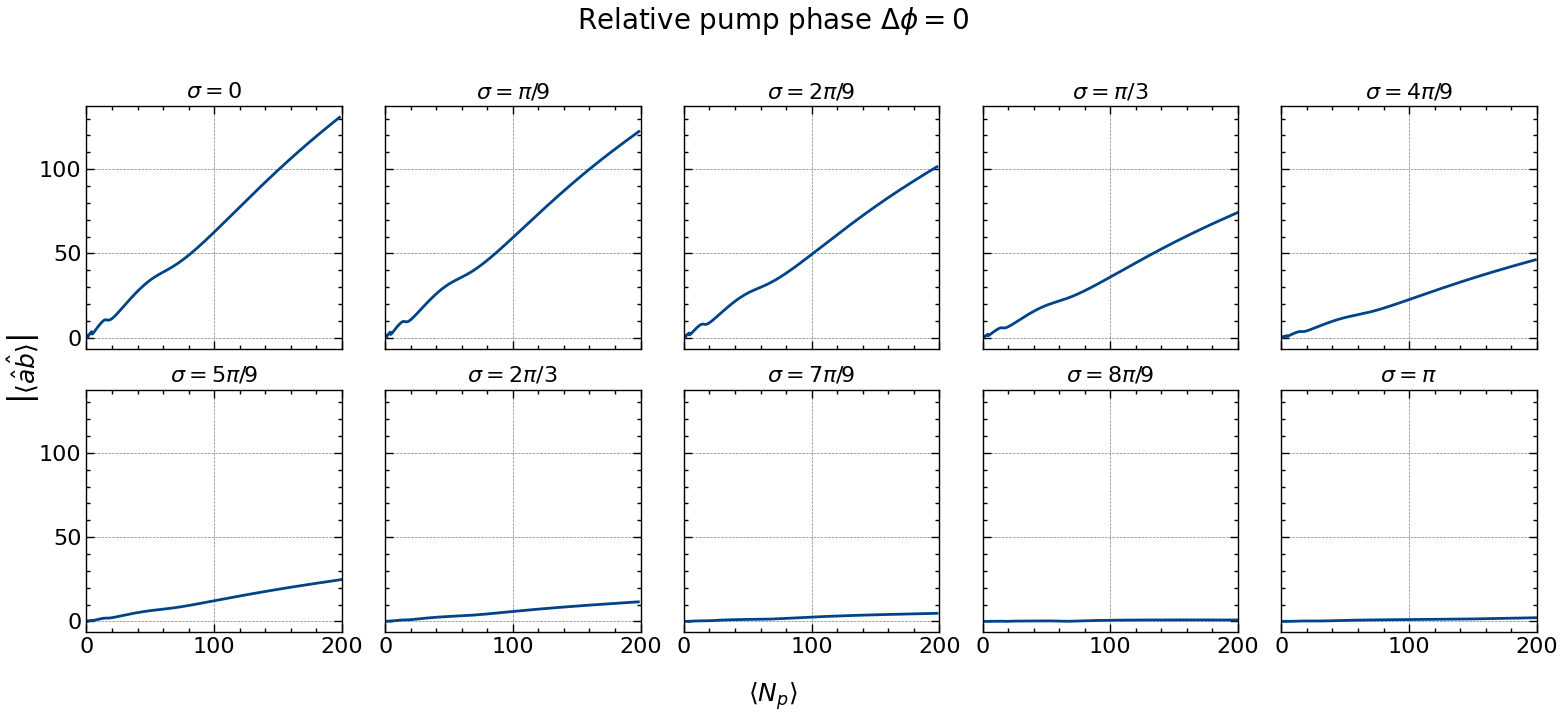

In [70]:
fig, axes = plot_pair_coherence_magnitude_grid(phi_index=0)
plt.savefig("plots/pair_coherence_magnitude_phi_0.pdf", dpi=500, bbox_inches="tight")
plt.show()

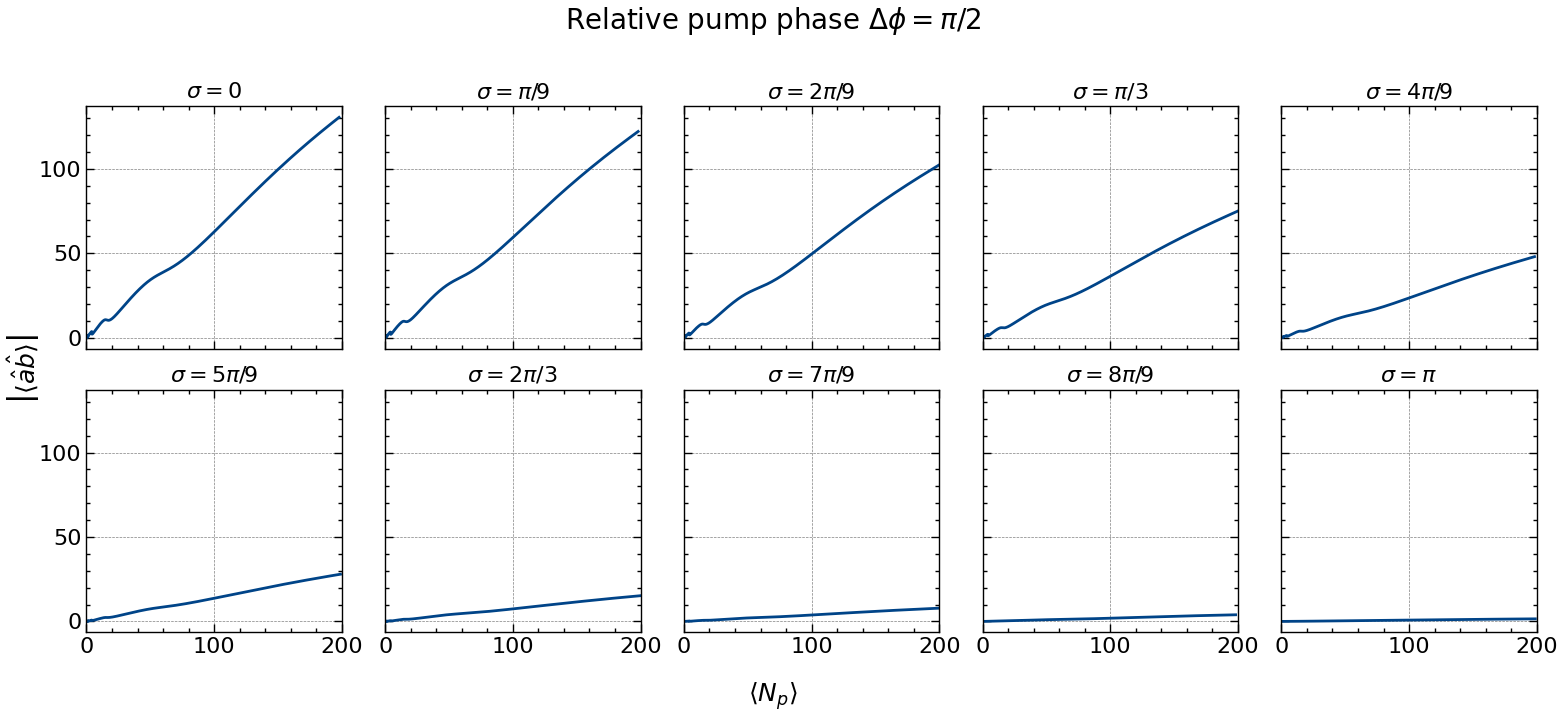

In [71]:
fig, axes = plot_pair_coherence_magnitude_grid(phi_index=1)
plt.savefig("plots/pair_coherence_magnitude_phi_pi_2.pdf", dpi=500, bbox_inches="tight")
plt.show()

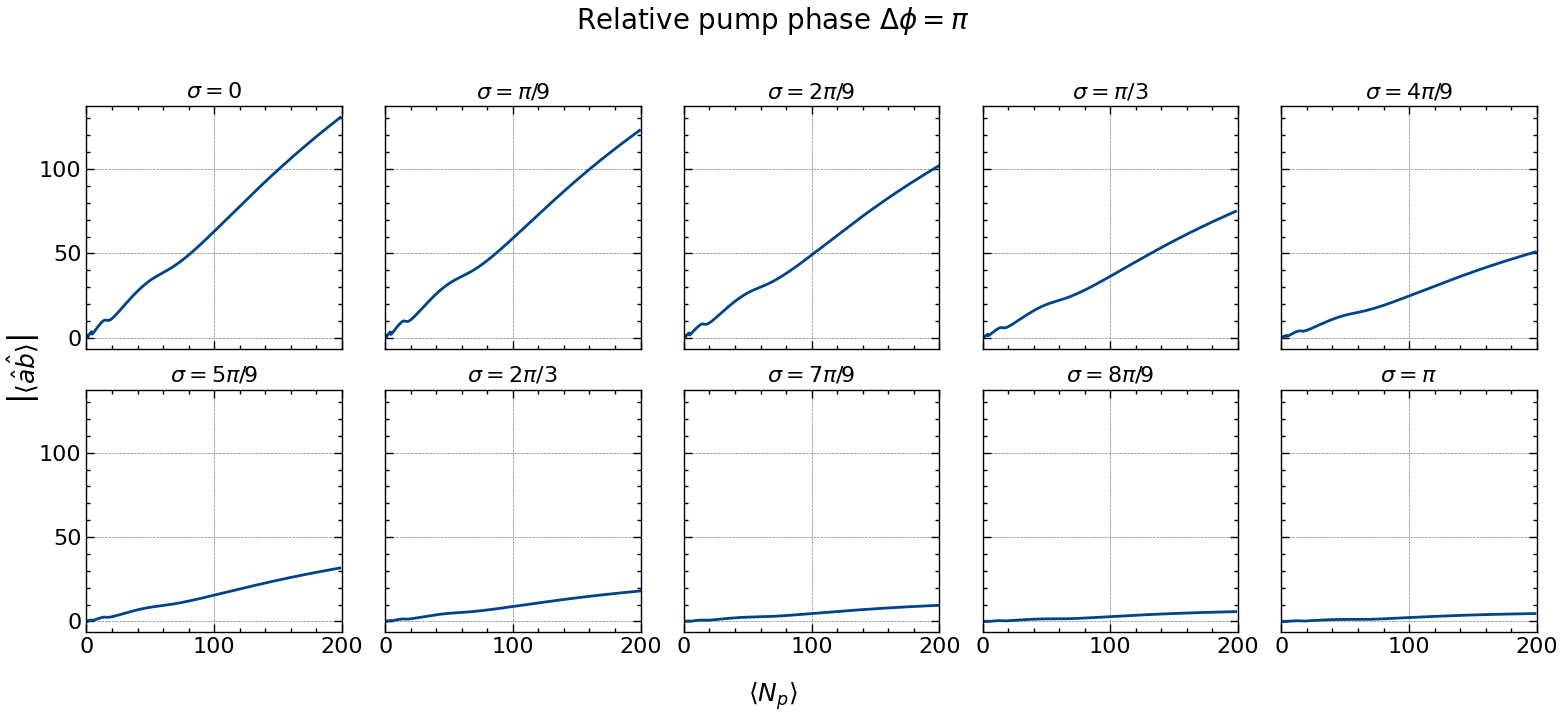

In [72]:
fig, axes = plot_pair_coherence_magnitude_grid(phi_index=2)
plt.savefig("plots/pair_coherence_magnitude_phi_pi.pdf", dpi=500, bbox_inches="tight")
plt.show()

In [73]:
# Pair-coherence phase versus mean pair number

def plot_pair_coherence_phase_grid(
    phi_index,
    pair_number_max=200.0,
    magnitude_fraction_cutoff=1e-3,
):
    """
    Plot the pair-coherence phase versus mean pair number
    for all ten phase-noise widths at one fixed relative pump phase.
    """

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(16, 7),
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    for sigma_index, ax in enumerate(axes):

        result = phase_sweep_data[
            (phi_index, sigma_index)
        ]

        channel = (
            result["observables"]
            .pair_channels["minus"]
        )

        pair_number = np.asarray(
            channel.pair_number.mean,
            dtype=float,
        )

        pair_coherence = np.asarray(
            channel.pair_coherence.mean,
            dtype=complex,
        )

        coherence_magnitude = np.abs(
            pair_coherence
        )

        magnitude_cutoff = (
            magnitude_fraction_cutoff
            * np.nanmax(coherence_magnitude)
        )

        valid = (
            np.isfinite(pair_number)
            & np.isfinite(pair_coherence.real)
            & np.isfinite(pair_coherence.imag)
            & (pair_number > 0.0)
            & (pair_number <= pair_number_max)
            & (coherence_magnitude > magnitude_cutoff)
        )

        pair_number_plot = pair_number[
            valid
        ]

        coherence_plot = pair_coherence[
            valid
        ]

        phase_plot = (
            np.unwrap(
                np.angle(coherence_plot)
            )
            / np.pi
        )

        ax.plot(
            pair_number_plot,
            phase_plot,
            linewidth=2.0,
        )

        ax.set_xlim(
            0.0,
            pair_number_max,
        )

        ax.set_ylim(-1.1, 1.1)
        
        ax.set_title(
            rf"$\sigma={sigma_labels[sigma_index][1:-1]}$"
        )

    fig.supxlabel(
        r"$\langle N_p\rangle$",
        fontsize=18
    )

    fig.supylabel(
        r"$\arg\!\left(\langle\hat{a}\hat{b}\rangle\right)/\pi$",
        fontsize=18
    )

    fig.suptitle(
        r"Relative pump phase "
        rf"$\Delta\phi="
        rf"{delta_phi_labels[phi_index][1:-1]}$",
        y=1.02,
        fontsize=20
    )

    fig.tight_layout()

    return fig, axes

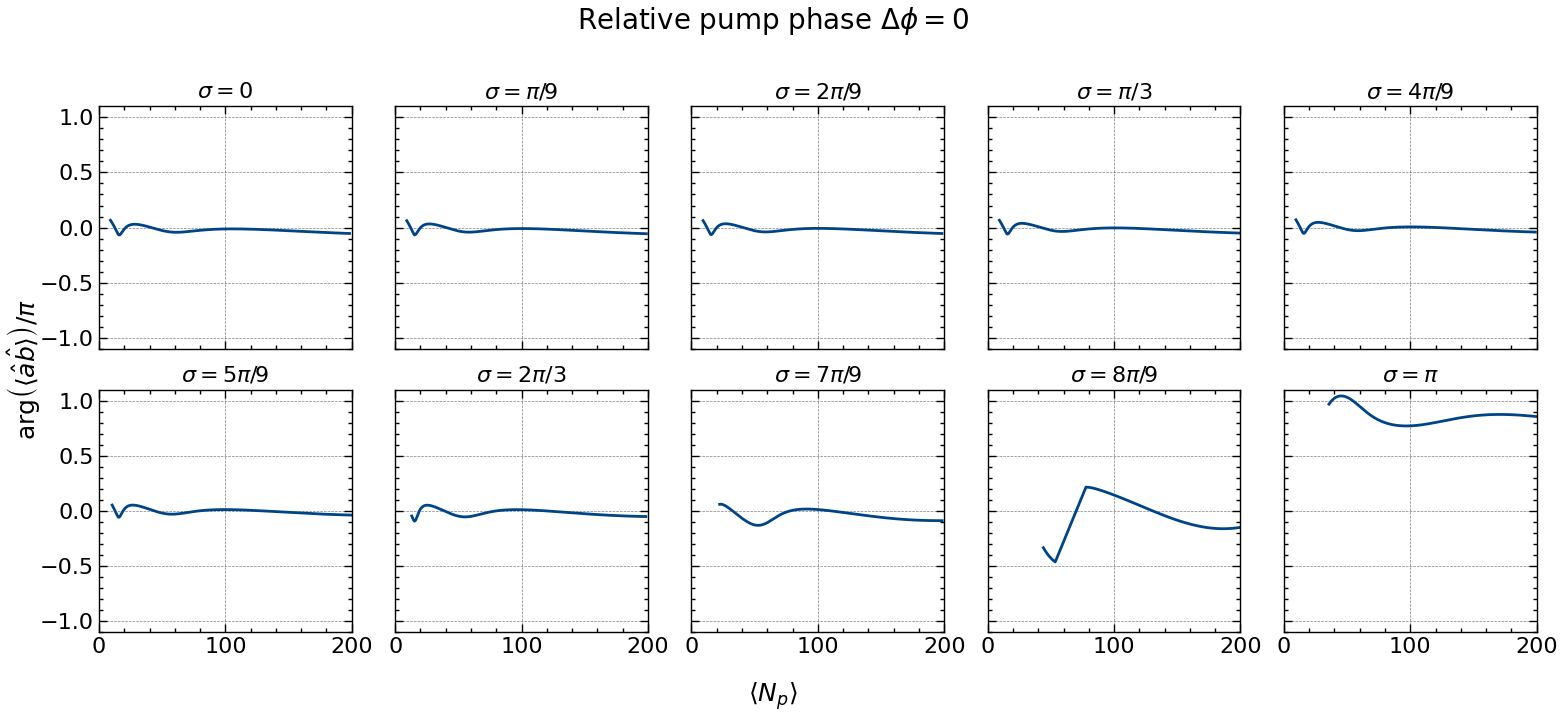

In [74]:
fig, axes = plot_pair_coherence_phase_grid(phi_index=0)
fig.savefig("plots/pair_coherence_phase_phi_0.pdf", dpi=500, bbox_inches="tight")
plt.show()

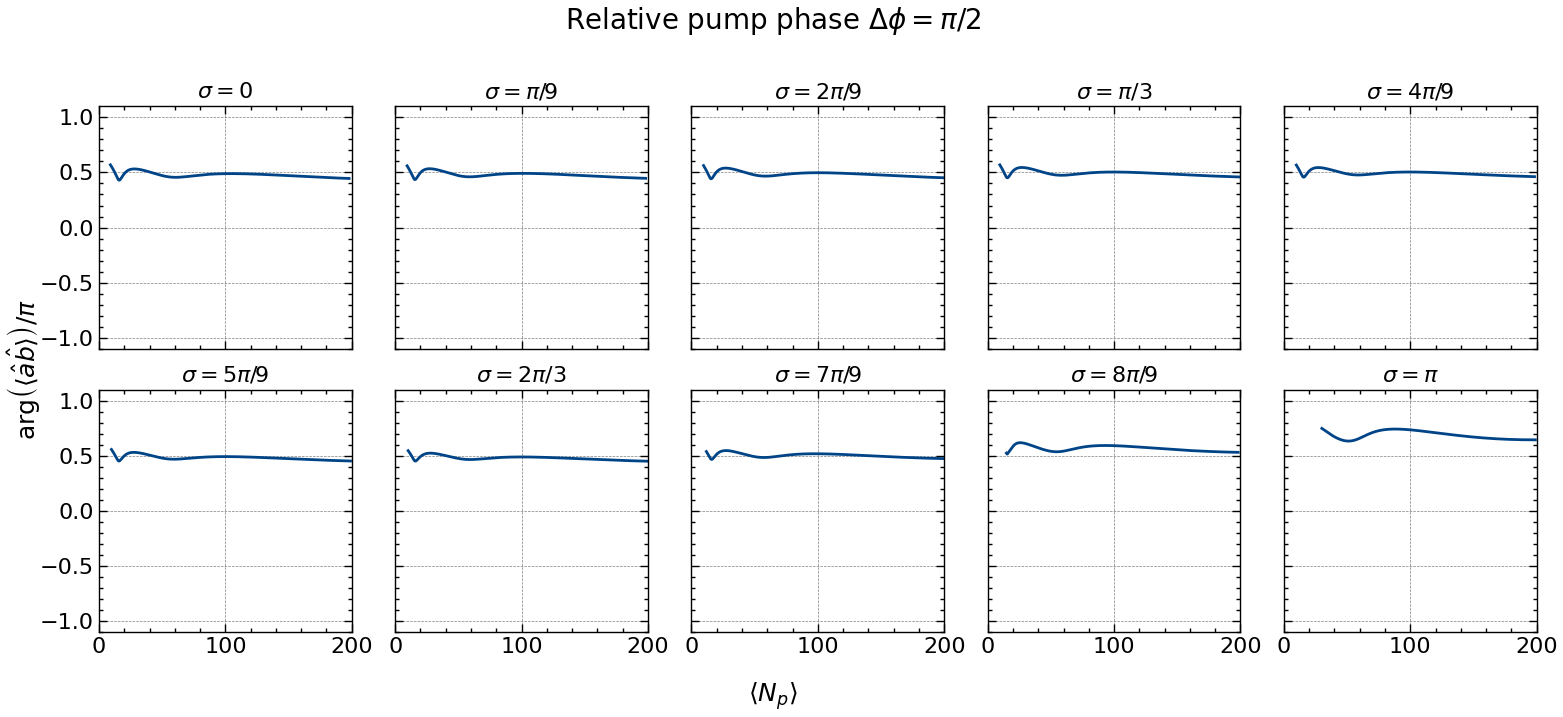

In [75]:
fig, axes = plot_pair_coherence_phase_grid(phi_index=1)
fig.savefig("plots/pair_coherence_phase_phi_pi_2.pdf", dpi=500, bbox_inches="tight")
plt.show()

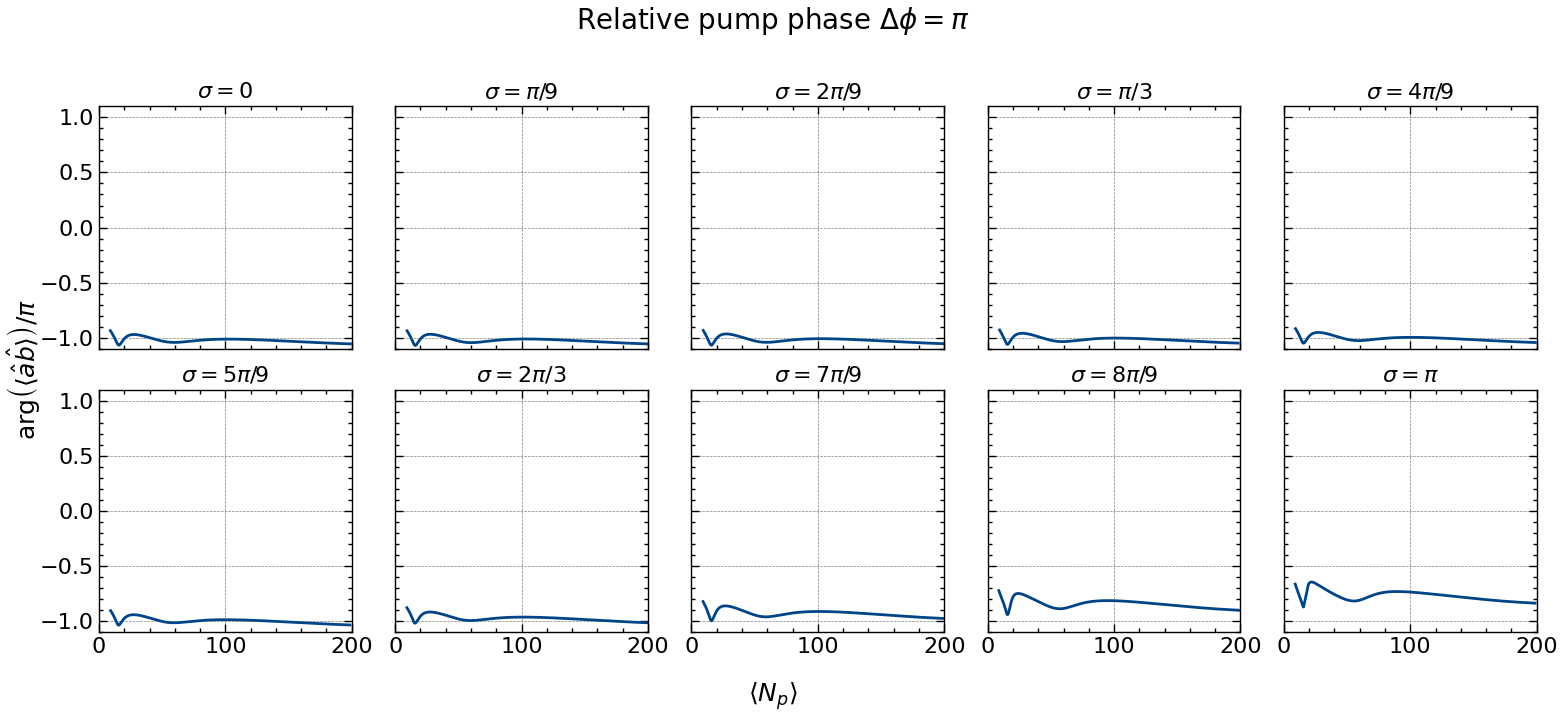

In [76]:
fig, axes = plot_pair_coherence_phase_grid(phi_index=2)
fig.savefig("plots/pair_coherence_phase_phi_pi.pdf", dpi=500, bbox_inches="tight")
plt.show()

### Cauchy-Schwarz ratio

In [77]:
# Cauchy-Schwarz ratio versus mean pair number

def plot_cauchy_schwarz_grid(
    phi_index,
    pair_number_max=10.0,
):
    """
    Plot the Cauchy-Schwarz ratio versus mean pair number
    for all ten phase-noise widths at one fixed relative pump phase.
    """

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(16, 7),
        sharex=True,
        sharey=True,
    )

    axes = axes.flatten()

    for sigma_index, ax in enumerate(axes):

        result = phase_sweep_data[
            (phi_index, sigma_index)
        ]

        channel = (
            result["observables"]
            .pair_channels["minus"]
        )

        pair_number = np.asarray(
            channel.pair_number.mean,
            dtype=float,
        )

        cauchy_schwarz_ratio = np.asarray(
            channel.cauchy_schwarz_ratio,
            dtype=float,
        )

        valid = (
            np.isfinite(pair_number)
            & np.isfinite(cauchy_schwarz_ratio)
            & (pair_number > 0.0)
            & (pair_number <= pair_number_max)
            & (cauchy_schwarz_ratio > 0.0)
        )

        pair_number_plot = pair_number[
            valid
        ]

        cauchy_schwarz_plot = cauchy_schwarz_ratio[
            valid
        ]

        ax.plot(
            pair_number_plot,
            cauchy_schwarz_plot,
            linewidth=2.0,
        )

        ax.axhline(
            1.0,
            color="grey",
            linestyle="--",
            linewidth=1.3,
        )

        ax.set_xlim(
            0.0,
            pair_number_max,
        )

        ax.set_yscale("log")

        ax.set_title(
            rf"$\sigma={sigma_labels[sigma_index][1:-1]}$"
        )

    fig.supxlabel(
        r"$\langle N_p\rangle$",
        fontsize=18
    )

    fig.supylabel(
        r"$\mathcal{C}$",
        fontsize=18
    )

    fig.suptitle(
        r"Relative pump phase "
        rf"$\Delta\phi="
        rf"{delta_phi_labels[phi_index][1:-1]}$",
        y=1.02,
        fontsize=20
    )

    fig.tight_layout()

    return fig, axes

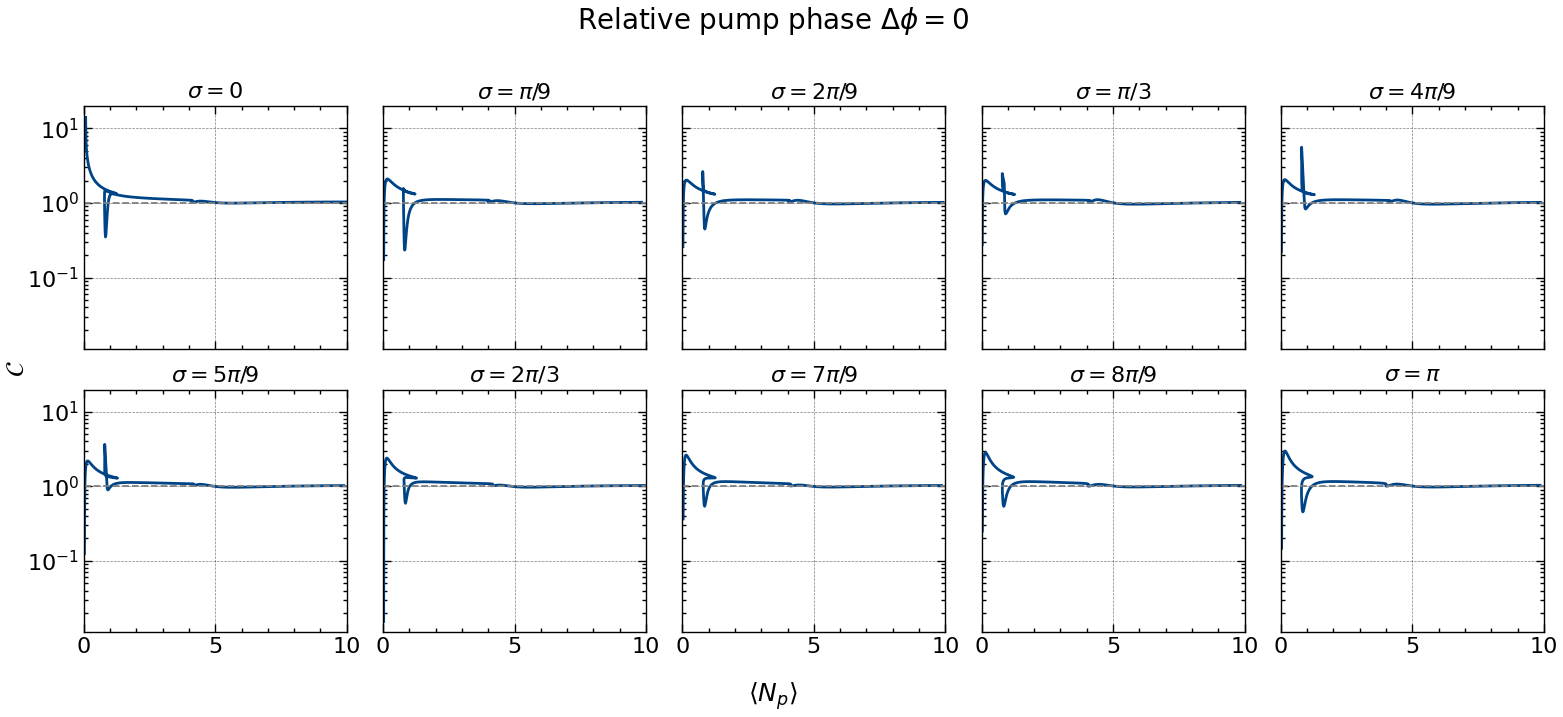

In [78]:
fig, axes = plot_cauchy_schwarz_grid(phi_index=0)
fig.savefig("plots/cauchy_schwarz_phi_0.pdf", dpi=500, bbox_inches="tight")
plt.show()

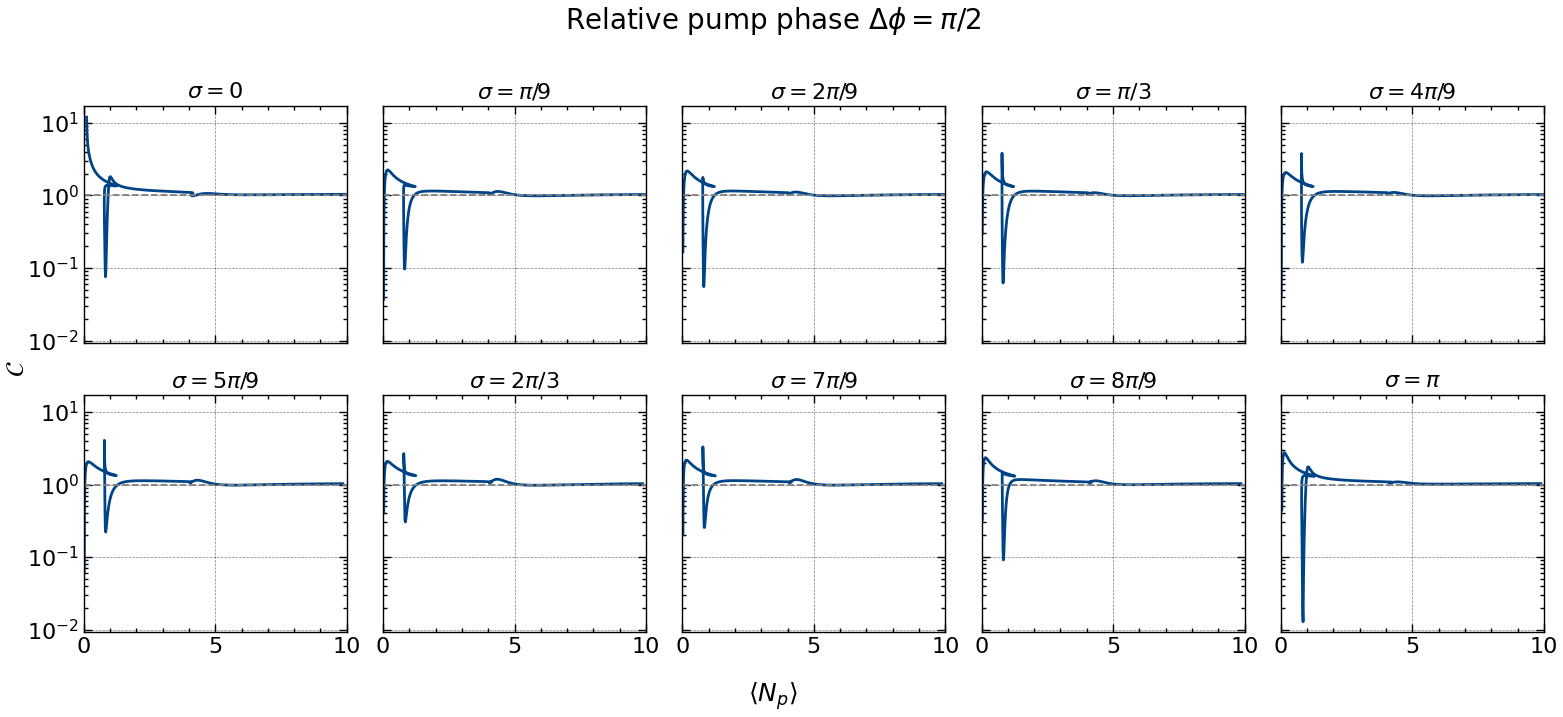

In [79]:
fig, axes = plot_cauchy_schwarz_grid(phi_index=1)
fig.savefig("plots/cauchy_schwarz_phi_pi_2.pdf", dpi=500, bbox_inches="tight")
plt.show()

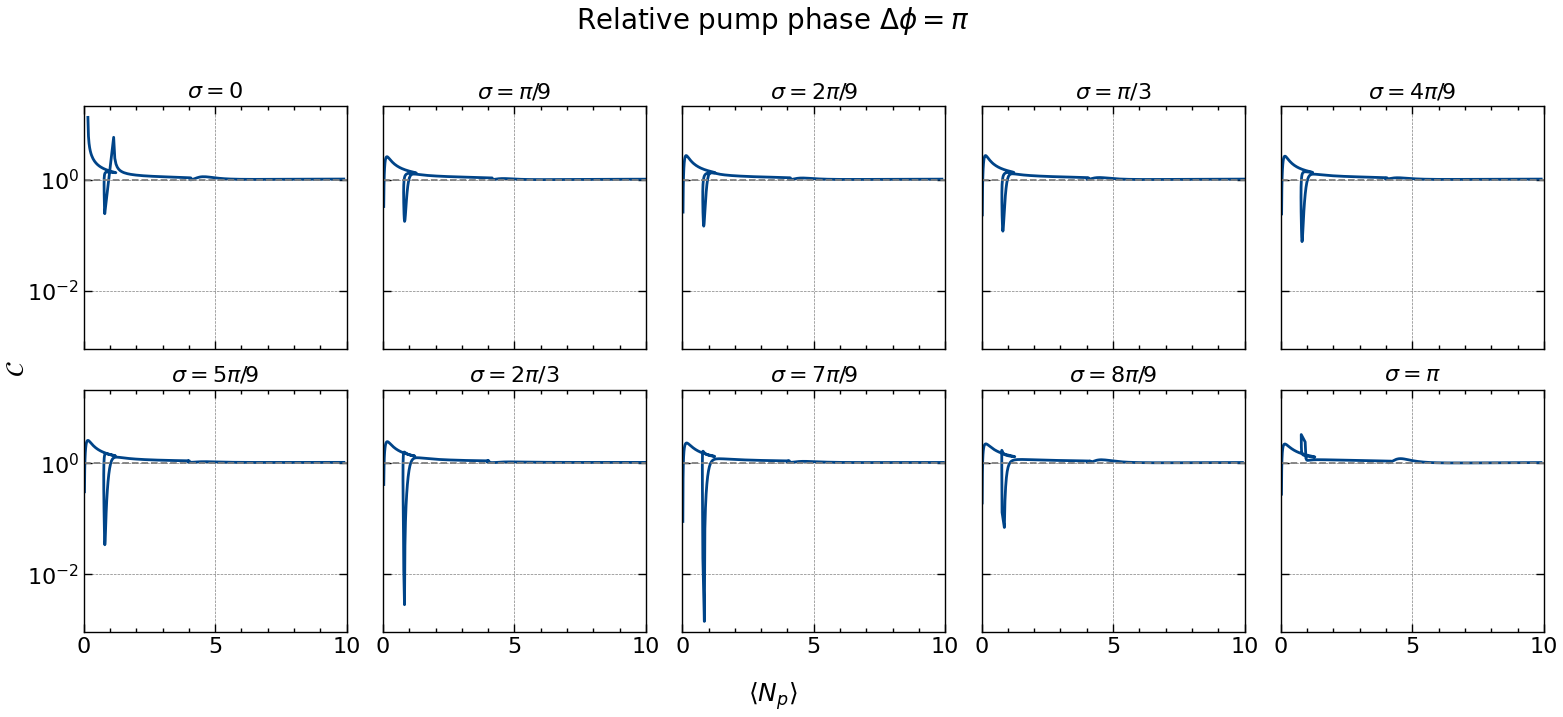

In [80]:
fig, axes = plot_cauchy_schwarz_grid(phi_index=2)
fig.savefig("plots/cauchy_schwarz_phi_pi.pdf", dpi=500, bbox_inches="tight")
plt.show()